# Overview

This assignment introduces linear classifiers (perceptrons), nonlinear neural networks, regularization, and visualization of decision boundaries.

All implementation must be done in NumPy **only** (no PyTorch, TensorFlow, JAX, or sklearn for training).


Ensure your code is well-commented and easy to understand.


In [138]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder

# Part 1 – Implement a Single Perceptron

## Implement the Perceptron Class

### Class Methods to Implement:

- `__init__(self, input_dim, lr=0.01)`  
  Initialize the weight vector `w` and bias `b`, and set the learning rate `η`.

- `forward(self, X)`  
  Compute the predicted output using the **step activation function**:
  $$
  \hat{y} = f(w^{\top} X + b), \quad
  f(z) =
  \begin{cases}
    1 & \text{if } z > 0 \\
    0 & \text{otherwise}
  \end{cases}
  $$

- `train_step(self, X, y)`  
  Update the weights and bias using the **perceptron learning rule**:
  $$
  w \leftarrow w + \eta (y - \hat{y}) X
  $$
  $$
  b \leftarrow b + \eta (y - \hat{y})
  $$

### Notes:

- $X$ is the input data. In `forward`, handle both single samples `(D,)` and batches `(N, D)`.
- $w$ is the weight vector, $b$ is the bias, and $\eta$ is the learning rate.
- Output $y$ should be `{0, 1}` (matching the data).
- Implement all computations manually using **NumPy**.
- `train_step` performs one update for a **single sample**.


In [139]:
class Perceptron:
  def __init__(self, input_dim, lr=0.1):
    self.lr = lr
    self.w = np.zeros(input_dim) # add input_dim to create zeroed out weights vector
    self.b = 0.0

  def forward(self, x):
    """
    x: numpy array shape (D,) for single sample, or (N, D) for N samples
    returns: 0 or 1 for single sample, or numpy array of 0s and 1s for N samples
    """
    if len(x.shape) == 1: # handle single inputs - if just a vector input the .shape has 1 dimension
      x = x.reshape(1, -1) # reshape into a 1 x D row vector matrix
    out = np.matmul(x, self.w) # numpy .matmul treat weights vector as a column vector on the right
    # and dot product it into all the rows (inputs) of x matrix, outputs a vector of dot products
    out += self.b # add the scalar bias to the vector of outputs
    out = (out >= 0).astype(int) # apply the thresholding function
    # return integer value (1 or 0) of the boolean expression of element >= 0 for all elements
    return out
    
  def train_step(self, x, y):
    """
    Performs a single perceptron update:
    w <- w + lr * (y - y_pred) * x
    b <- b + lr * (y - y_pred)

    Learns on ONE SINGLE POINT
    """
    pred = self.forward(x) # forward pass for prediction
    error = y - pred # find error of prediction (direction of change) - either it is 0, or +1/-1.
    self.b += self.lr * (error)
    self.w += self.lr * (error) * x # since x is a single data point it is just a vector
    # so it can be multiplied by these scalars and add directly to vector of weights

## Test the model on a few sample inputs to ensure that the output is always 0 or 1.


In [140]:
p = Perceptron(input_dim = 2, lr = 0.1)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0,0,0,1])   # AND gate

for epoch in range(10):
    for x, y in zip(X, Y):
        p.train_step(x, y)

print("Weights:", p.w)
print("Bias:", p.b)

for x in X:
    print(x, "->", p.forward(x))

Weights: [0.2 0.1]
Bias: [-0.2]
[0 0] -> [0]
[0 1] -> [0]
[1 0] -> [0]
[1 1] -> [1]


## Generate a 2D Toy Dataset

### Task

Generate a simple **2D dataset** for binary classification.

**Requirements:**
- The dataset must be **partially - linearly separable** (meaning a straight line can separate the two classes, but not perfectly). If the data is highly non-linearly separable, the single-layer perceptron will not converge.
- You can use `sklearn.datasets.make_moons` or generate random points manually to experiment.
- Visualize the dataset using a scatter plot to verify partial-linear separability.


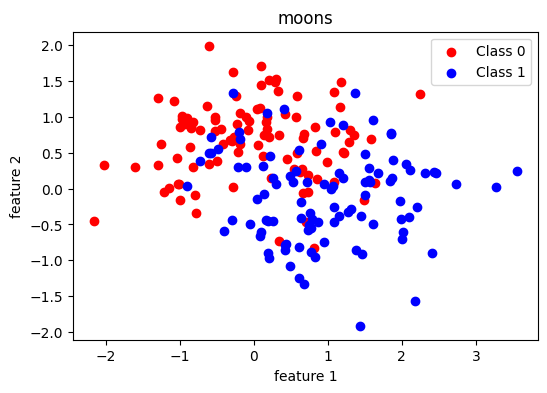

In [141]:
X, y = make_moons(n_samples=200, noise=0.5, random_state=67)

class_0 = X[y == 0] # boolean masks to seperate out classes 0 vs 1
class_1 = X[y == 1]

plt.figure(figsize=(6, 4))
# plot all rows (point values) for class_0 and class_1
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')
plt.title("moons")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.show()

## Train the Perceptron

### Task

- Train your perceptron on the generated dataset.
- Iterate for multiple **epochs** (passes over the entire dataset).
- Calculate and print the **training accuracy** after each epoch.
- **Expectation**: Since you generated a partially-linearly separable data, the perceptron should reach **>70% accuracy** fairly quickly, but probably doesn't go above 90.


In [142]:
# using test code setup from above
p = Perceptron(input_dim=2, lr=0.1)

for epoch in range(10):
    for x_i, y_i in zip(X, y):
        p.train_step(x_i, y_i)
    # Predict on all data
    preds = p.forward(X).flatten()
    acc = np.mean(preds == y)
    print(f"Epoch {epoch+1}: Training accuracy = {acc*100:.2f}%")

Epoch 1: Training accuracy = 81.00%
Epoch 2: Training accuracy = 80.00%
Epoch 3: Training accuracy = 78.00%
Epoch 4: Training accuracy = 75.50%
Epoch 5: Training accuracy = 81.00%
Epoch 6: Training accuracy = 79.00%
Epoch 7: Training accuracy = 81.00%
Epoch 8: Training accuracy = 76.00%
Epoch 9: Training accuracy = 81.00%
Epoch 10: Training accuracy = 80.50%


## Visualize the Decision Boundary

### Task

- Plot the decision boundary learned by your perceptron along with the data points.
- **Visualizing the Boundary**: Create a meshgrid over the input space, predict the class for every point in the grid, and plot the contours.
- **Observation**: You should see a **straight line** separating the two classes, confirming that the single-layer perceptron is a linear classifier.


### Create a meshgrid

In [143]:
# create extra room in overall grid from bottom and top points to extend visual
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
# xx and yy are meshgrid points to test class predictions, made by quick linspace of 300 points
# I actually tried using 1000x1000 meshgrid but it took too long to evaluate 
# somehow (more than 1min so I quit it)
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
# xx for meshgrid extended x values, yy for meshgrid extended y values

### Evaluate perceptron prediction on grid

In [144]:
Z = []
for i in range(len(xx.flatten())): 
    # loop through all point combinations
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    # add the point combination output prediction to Z
    Z.append(p.forward(point))
# reshape in the same way it was flattened
Z = np.array(Z).reshape(xx.shape)

### Plot contour

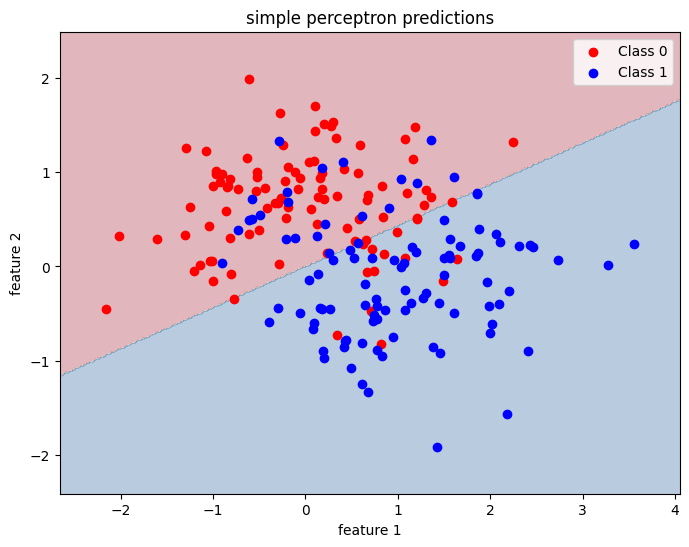

In [145]:
plt.figure(figsize=(8, 6))
# plot mesh grid values with predictions Z
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("simple perceptron predictions")
plt.legend()
plt.show()

# Part 2 – Implement a Two-Layer Sigmoid Network (NumPy Only)

In this part, you will implement and train a **two-layer fully connected neural network** using the **sigmoid activation function**. All computations must be implemented **manually using NumPy** (no automatic differentiation or deep learning frameworks).

---

## Model Definition

The network has the following form:

$$
h = \sigma(x W_1 + b_1)
$$

$$
\hat{y} = \sigma(h W_2 + b_2)
$$

where:

- $x \in \mathbb{R}^{d}$ is the input,
- $W_1 \in \mathbb{R}^{d \times h},\ b_1 \in \mathbb{R}^{h}$,
- $W_2 \in \mathbb{R}^{h \times 1},\ b_2 \in \mathbb{R}$,
- $h$ is the hidden layer dimension,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the **sigmoid activation function**.

---

## Loss Function

Use **binary cross-entropy (BCE)** as the training loss:

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^N \Big[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big]
$$

- This is suitable for binary classification problems.
- Ensure that the network output $\hat{y}$ is in the range $[0, 1]$ by using a sigmoid activation in the output layer.

---

## Required Methods

Your network class should include at least the following methods:

- `__init__(self, input_dim, hidden_dim, lr)`  
  Initialize weights and biases.

- `forward(self, X)`  
  Compute the forward pass and return the network output.

- `backward(self, X, y)`  
  Compute gradients of all parameters using backpropagation.

- `train(self, X, y, epochs)`  
  Train the network using gradient descent and report the training loss.

- `predict(self, X)`  
  Return predicted class labels (0 or 1) using a **0.5 threshold**.

You may add additional helper functions as needed (e.g., sigmoid, sigmoid derivative, loss, etc).

---

## Training Requirements

- Use **manual gradient descent** with a fixed learning rate.
- Do **not** use any automatic differentiation tools.
- All gradients must be derived and implemented explicitly.

---

### Tasks

- Implement a two-layer neural network with an **arbitrary hidden dimension**.
- Train the network on the **Toy dataset** from before.
- Visualize the learned non-linear decision boundry using a grid-based contour plot like before.
- Train the network on an Image called **Digits** (MNIST like).
- Visualize the loss curves and report your accuracy. 


In [ ]:
class NeuralNetwork:
  def __init__(self, input_size, hidden_size, output_size, lr = 0.1):
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.lr = lr

    # weight 1 is  a matrix such that when a batch of n inputs 
    # is provided, in dimension batch_size x input_size, the matrix multiplication
    # X * W1 is possible. So that means W1 must be of dimension input_size x hidden_size.
    # this means the matrix multiplication will produce output matrix of batch_size x hidden_size
    # so every element of the batch has a set of hidden layer inputs. perfect :)
    # continue logic to derive sizes for everything else (wait just saw they were given too)

    # W1: input_size x hidden_size (connects input to hidden layer)
    self.W1 = np.zeros((self.input_size, self.hidden_size))
    # b1: hidden_size (bias for each hidden neuron, added after W1 applies)
    self.b1 = np.zeros(self.hidden_size)
    # W2: hidden_size x 1 (connects hidden layer to output neuron)
    self.W2 = np.zeros((self.hidden_size, 1))
    # b2: bias for output neuron
    self.b2 = 0.0

  def sigmoid(self, x):
    return 1 / (1 + np.exp(-x))

  def sigmoid_derivative(self, x):
    # derivative of sigmoid = sigmoid(x) * (1 - sigmoid(x))
    s = self.sigmoid(x)
    return s * (1 - s)

  def calculate_loss(self, y_true, y_pred):
    # prevent y_pred from being exactly 0 (rare) for log(0) risk
    # clip it so if its ever exactly 1 or 0 it is fixed to barely not be
    anti_0 = 1e-8
    y_pred = np.clip(y_pred, anti_0, 1 - anti_0)
    # implementation of given equation - element wise operations summed and averaged
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

  def forward(self, x):
    # TODO: Implement forward pass
    pass

  def backward(self, x, y, learning_rate):
    # TODO: Implement backpropagation
    pass

  def train(self, x, y, epochs, learning_rate):
    # TODO: Implement training loop
    pass

  def predict(self, x):
    # TODO: Implement prediction (threshold at 0.5)
    pass


### Train on Toy Dataset

In [147]:
#TODO: preprocess dataset to be compatible with the NN model.

In [148]:
#TODO: Create a Neural Network object and train.

In [149]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

NameError: name 'losslist' is not defined

### Calculate the Accuracy of your trained Neural Network on the Toy dataset.


In [ ]:
def accuracy(y_true, y_pred):
   print("Accuracy:", (np.where(y_true==y_pred)[0].shape[0] / y_true.shape[0]) * 100, "%")

In [ ]:
preds = nn.predict(X)
accuracy(np.argmax(y,axis=1), preds)

### Visualize the Non-linear decision boundry

In [ ]:
# TODO: Create a meshgrid

In [ ]:
Z = []
for i in range(len(xx.flatten())):
    point = np.array([xx.flatten()[i], yy.flatten()[i]])
    Z.append(nn.predict(point))
Z = np.array(Z).reshape(xx.shape)

In [ ]:
# TODO: Plot contours using plt.contourf and points using plt.scatter

### Load the digits dataset from sklearn (MNIST Like).

In [ ]:
def normalize(X):
    return X/255.0

In [ ]:
X, y = load_digits(return_X_y=True)
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

In [ ]:
X = normalize(X)
y = y.reshape(-1,1)
enc = OneHotEncoder(handle_unknown='ignore')
y = enc.fit_transform(y).toarray()
print(f"Image Shape:{X.shape} Label Shape:{y.shape}")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Label: {np.argmax(y[i])}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Train your Neural Network

In [ ]:
# TODO: Train your Neural Network on the digits dataset

### Plot your training curve

In [ ]:
plt.plot(losslist)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

### Calculate the Accuracy of your trained Neural Network on Digits


In [ ]:
preds = nn.predict(X)
accuracy(np.argmax(y,axis=1), preds)